# 1. Dataset Overview

Replicate DeepLOB on FI-2010 Setup 2 using the top-10 bid/ask levels (40 features) and 100-step windows.

- Uses horizon `horizon_events` (default 5) from the label rows.
- Train on the first 7 days, validate on a hold-out split, test on the last 3 days.
- Files live under Assignment2/raw.

Label definition (DeepLOB):

$$
f_j^{(i)} = \frac{1}{k} \sum_{j=i+1}^{i+k} m_j - m_i
$$

where $m_i$ is current mid-price and $m_j$ are future mid-prices over horizon $k$.

**Data needed**

- Required: Train_Dst_NoAuction_ZScore_CF_7.txt (first 7 days).
- Provided: Test_Dst_NoAuction_ZScore_CF_7.txt, Test_Dst_NoAuction_ZScore_CF_8.txt, Test_Dst_NoAuction_ZScore_CF_9.txt.
- Row mapping in raw file: last 5 label rows correspond to $k \in \{1,2,3,5,10\}$.
- If you want to try other horizons, change `horizon_events` in the config cell.

In [1]:
import os
from pathlib import Path
from datetime import datetime
from tqdm import tqdm

import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda:0")
else:
    device = torch.device("cpu")
torch.manual_seed(42)
np.random.seed(42)
print(f"Running on {device}")

Running on mps


In [ ]:
RAW_DIR = (Path().resolve().parent / "raw").resolve()

cfg = {
    "train_file": RAW_DIR / "Train_Dst_NoAuction_ZScore_CF_7.txt",
    "test_files": [
        RAW_DIR / "Test_Dst_NoAuction_ZScore_CF_7.txt",
        RAW_DIR / "Test_Dst_NoAuction_ZScore_CF_8.txt",
        RAW_DIR / "Test_Dst_NoAuction_ZScore_CF_9.txt",
    ],
    "window": 100,
    "horizon_events": 5,  # choose from {1,2,3,5,10}
    "batch_size": 64,
    "lr": 1e-3,
    "weight_decay": 1e-5,
    "epochs": 50,
    "num_classes": 3,
    "val_ratio": 0.2,
    "checkpoint_path": Path("best_val_model_assignment2_full.pt"),
}
HORIZON_TO_INDEX = {1: 0, 2: 1, 3: 2, 5: 3, 10: 4}
CLASS_NAMES = ["up", "stationary", "down"]

print(f"Raw data folder: {RAW_DIR}")
for path in [cfg["train_file"], *cfg["test_files"]]:
    print(f"{path.name} exists: {path.exists()}")

Raw data folder: /Users/kaibiaozhu/Documents/GitHub/machine-learning-for-finance/Assignment2/raw
Train_Dst_NoAuction_ZScore_CF_7.txt exists: True
Test_Dst_NoAuction_ZScore_CF_7.txt exists: True
Test_Dst_NoAuction_ZScore_CF_8.txt exists: True
Test_Dst_NoAuction_ZScore_CF_9.txt exists: True


In [3]:
def load_raw_matrix(path: Path) -> np.ndarray:
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")
    data = np.loadtxt(path)
    return data.astype(np.float32)

pin_mem = torch.device(device).type == "cuda"
num_workers = 0  # avoid multiprocessing issues on macOS/mps

def stack_days(paths) -> np.ndarray:
    matrices = [load_raw_matrix(p) for p in paths]
    return np.hstack(matrices)

def build_sequences(raw_matrix: np.ndarray, window: int, horizon_events: int):
    if horizon_events not in HORIZON_TO_INDEX:
        valid = sorted(HORIZON_TO_INDEX.keys())
        raise ValueError(f"horizon_events={horizon_events} not in {valid}")

    features = raw_matrix[:40, :].T  # shape (events, 40)
    label_idx = HORIZON_TO_INDEX[horizon_events]
    labels = raw_matrix[-5:, :].T[:, label_idx] - 1  # map {1,2,3} -> {0,1,2}

    n_events, n_features = features.shape
    if n_events <= window:
        raise ValueError(f"Not enough events ({n_events}) for window {window}")

    shape = (n_events - window + 1, window, n_features)
    strides = (features.strides[0], features.strides[0], features.strides[1])
    windows = np.lib.stride_tricks.as_strided(features, shape=shape, strides=strides).copy()
    labels = labels[window - 1 :]
    return windows.astype(np.float32), labels.astype(np.int64)

class LobDataset(Dataset):
    def __init__(self, x: np.ndarray, y: np.ndarray):
        self.x = torch.from_numpy(x).unsqueeze(1)  # (N, 1, T, 40)
        self.y = torch.from_numpy(y)

    def __len__(self):
        return self.x.shape[0]

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

def make_loaders(train_raw: np.ndarray, test_raw: np.ndarray, cfg: dict, horizon_events=None):
    horizon = cfg["horizon_events"] if horizon_events is None else horizon_events

    x_train, y_train = build_sequences(train_raw, cfg["window"], horizon)
    split = int(len(x_train) * (1 - cfg["val_ratio"]))
    train_ds = LobDataset(x_train[:split], y_train[:split])
    val_ds = LobDataset(x_train[split:], y_train[split:])

    x_test, y_test = build_sequences(test_raw, cfg["window"], horizon)
    test_ds = LobDataset(x_test, y_test)

    loaders = {
        "train": DataLoader(train_ds, batch_size=cfg["batch_size"], shuffle=True, drop_last=True, num_workers=num_workers, pin_memory=pin_mem),
        "val": DataLoader(val_ds, batch_size=cfg["batch_size"], shuffle=False, num_workers=num_workers, pin_memory=pin_mem),
        "test": DataLoader(test_ds, batch_size=cfg["batch_size"], shuffle=False, num_workers=num_workers, pin_memory=pin_mem),
    }
    return loaders, {"train": train_ds, "val": val_ds, "test": test_ds}

def build_loaders_for_horizon(horizon_events: int, cfg: dict, train_raw: np.ndarray, test_raw: np.ndarray):
    return make_loaders(train_raw, test_raw, cfg, horizon_events=horizon_events)

In [4]:
DATA_AVAILABLE = True
try:
    train_raw = load_raw_matrix(cfg["train_file"])
    test_raw = stack_days(cfg["test_files"])
    loaders, datasets = make_loaders(train_raw, test_raw, cfg)
    print(f"Train windows: {len(datasets['train'])}, Val windows: {len(datasets['val'])}, Test windows: {len(datasets['test'])}")
except FileNotFoundError as exc:
    DATA_AVAILABLE = False
    print(exc)

Train windows: 203720, Val windows: 50931, Test windows: 139488


# 2. Model Architecture

This section implements a PyTorch version of DeepLOB (Conv blocks + Inception-style branches + LSTM).

In [5]:
class DeepLOB(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=(1, 2), stride=(1, 2)),
            nn.LeakyReLU(0.01),
            nn.BatchNorm2d(32),
            nn.Conv2d(32, 32, kernel_size=(4, 1)),
            nn.LeakyReLU(0.01),
            nn.BatchNorm2d(32),
            nn.Conv2d(32, 32, kernel_size=(4, 1)),
            nn.LeakyReLU(0.01),
            nn.BatchNorm2d(32),
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 32, kernel_size=(1, 2), stride=(1, 2)),
            nn.Tanh(),
            nn.BatchNorm2d(32),
            nn.Conv2d(32, 32, kernel_size=(4, 1)),
            nn.Tanh(),
            nn.BatchNorm2d(32),
            nn.Conv2d(32, 32, kernel_size=(4, 1)),
            nn.Tanh(),
            nn.BatchNorm2d(32),
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(32, 32, kernel_size=(1, 10)),
            nn.LeakyReLU(0.01),
            nn.BatchNorm2d(32),
            nn.Conv2d(32, 32, kernel_size=(4, 1)),
            nn.LeakyReLU(0.01),
            nn.BatchNorm2d(32),
            nn.Conv2d(32, 32, kernel_size=(4, 1)),
            nn.LeakyReLU(0.01),
            nn.BatchNorm2d(32),
        )
        self.inp1 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=(1, 1), padding="same"),
            nn.LeakyReLU(0.01),
            nn.BatchNorm2d(64),
            nn.Conv2d(64, 64, kernel_size=(3, 1), padding="same"),
            nn.LeakyReLU(0.01),
            nn.BatchNorm2d(64),
        )
        self.inp2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=(1, 1), padding="same"),
            nn.LeakyReLU(0.01),
            nn.BatchNorm2d(64),
            nn.Conv2d(64, 64, kernel_size=(5, 1), padding="same"),
            nn.LeakyReLU(0.01),
            nn.BatchNorm2d(64),
        )
        self.inp3 = nn.Sequential(
            nn.MaxPool2d((3, 1), stride=(1, 1), padding=(1, 0)),
            nn.Conv2d(32, 64, kernel_size=(1, 1), padding="same"),
            nn.LeakyReLU(0.01),
            nn.BatchNorm2d(64),
        )
        self.lstm = nn.LSTM(input_size=192, hidden_size=64, num_layers=1, batch_first=True)
        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
        h0 = torch.zeros(1, x.size(0), 64, device=x.device)
        c0 = torch.zeros(1, x.size(0), 64, device=x.device)

        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)

        x = torch.cat([self.inp1(x), self.inp2(x), self.inp3(x)], dim=1)
        x = x.permute(0, 2, 1, 3)
        x = torch.reshape(x, (-1, x.shape[1], x.shape[2]))

        x, _ = self.lstm(x, (h0, c0))
        x = x[:, -1, :]
        logits = self.fc(x)
        return logits

if DATA_AVAILABLE:
    model = DeepLOB(cfg["num_classes"]).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    print(model.fc)
else:
    model = None

Linear(in_features=64, out_features=3, bias=True)


In [ ]:
def make_empty_history():
    return {
        "train_loss": [],
        "val_loss": [],
        "val_acc": [],
        "val_macro_f1": [],
        "val_weighted_f1": [],
    }


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    losses = []
    for x, y in loader:
        x = x.to(device, dtype=torch.float32)
        y = y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return float(np.mean(losses))


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    losses = []
    all_targets = []
    all_preds = []

    for x, y in loader:
        x = x.to(device, dtype=torch.float32)
        y = y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        preds = torch.argmax(logits, dim=1)

        losses.append(loss.item())
        all_targets.append(y.detach().cpu().numpy())
        all_preds.append(preds.detach().cpu().numpy())

    if not all_targets:
        return {
            "loss": float("nan"),
            "acc": 0.0,
            "macro_f1": 0.0,
            "weighted_f1": 0.0,
            "report": "No samples.",
            "y_true": np.array([], dtype=np.int64),
            "y_pred": np.array([], dtype=np.int64),
        }

    y_true = np.concatenate(all_targets)
    y_pred = np.concatenate(all_preds)

    acc = float((y_pred == y_true).mean())
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    report = classification_report(
        y_true,
        y_pred,
        labels=[0, 1, 2],
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0,
    )

    return {
        "loss": float(np.mean(losses)),
        "acc": acc,
        "macro_f1": float(macro_f1),
        "weighted_f1": float(weighted_f1),
        "report": report,
        "y_true": y_true,
        "y_pred": y_pred,
    }


def save_training_checkpoint(path, model, optimizer, best_val_macro_f1, history, epoch):
    payload = {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_val_macro_f1": float(best_val_macro_f1),
        "history": history,
        "epoch": int(epoch),
        "checkpoint_format": "full_training_state_v1",
    }
    torch.save(payload, path)


def load_training_checkpoint(path, model, optimizer=None, map_location=None):
    ckpt = torch.load(path, map_location=map_location)

    if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
        model.load_state_dict(ckpt["model_state_dict"])
        if optimizer is not None and "optimizer_state_dict" in ckpt:
            optimizer.load_state_dict(ckpt["optimizer_state_dict"])

        history = ckpt.get("history", make_empty_history())
        best_val_macro_f1 = float(ckpt.get("best_val_macro_f1", -1.0))
        epoch = int(ckpt.get("epoch", -1))
        checkpoint_type = ckpt.get("checkpoint_format", "full_training_state")
    else:
        model.load_state_dict(ckpt)
        history = make_empty_history()
        best_val_macro_f1 = -1.0
        epoch = -1
        checkpoint_type = "weights_only"

    return {
        "history": history,
        "best_val_macro_f1": best_val_macro_f1,
        "epoch": epoch,
        "checkpoint_type": checkpoint_type,
    }


def extract_model_state_dict(path, map_location=None):
    ckpt = torch.load(path, map_location=map_location)
    if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
        return ckpt["model_state_dict"]
    return ckpt


def plot_confusion(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    return cm

# 3. Training Protocol

- Optimizer: Adam
- Loss: CrossEntropyLoss
- Best checkpoint criterion: validation Macro F1 (to handle class imbalance)
- Metrics tracked each epoch: train loss, val loss, val accuracy, val Macro/Weighted F1

In [ ]:
history = make_empty_history()

if not DATA_AVAILABLE:
    best_val_macro_f1 = -1.0
    print("Training skipped: add Train_Dst_NoAuction_ZScore_CF_7.txt to Assignment2/raw.")
else:
    if cfg["checkpoint_path"].exists():
        print("Found existing checkpoint, loading weights and skipping training loop...")
        loaded = load_training_checkpoint(
            cfg["checkpoint_path"],
            model,
            optimizer=optimizer,
            map_location=device,
        )
        history = loaded["history"]
        best_val_macro_f1 = loaded["best_val_macro_f1"]

        val_metrics = evaluate(model, loaders["val"], criterion)
        best_val_macro_f1 = max(best_val_macro_f1, val_metrics["macro_f1"])

        print(f"Checkpoint type: {loaded['checkpoint_type']}")
        print(
            f"Loaded checkpoint validation metrics | "
            f"val_loss {val_metrics['loss']:.4f} | "
            f"val_acc {val_metrics['acc']:.4f} | "
            f"val_macro_f1 {val_metrics['macro_f1']:.4f} | "
            f"val_weighted_f1 {val_metrics['weighted_f1']:.4f}"
        )
    else:
        best_val_macro_f1 = -1.0
        for epoch in tqdm(range(cfg["epochs"]), desc="Epochs"):
            train_loss = train_one_epoch(model, loaders["train"], criterion, optimizer)
            val_metrics = evaluate(model, loaders["val"], criterion)

            history["train_loss"].append(train_loss)
            history["val_loss"].append(val_metrics["loss"])
            history["val_acc"].append(val_metrics["acc"])
            history["val_macro_f1"].append(val_metrics["macro_f1"])
            history["val_weighted_f1"].append(val_metrics["weighted_f1"])

            improved = val_metrics["macro_f1"] > best_val_macro_f1
            if improved:
                best_val_macro_f1 = val_metrics["macro_f1"]
                save_training_checkpoint(
                    cfg["checkpoint_path"],
                    model,
                    optimizer,
                    best_val_macro_f1,
                    history,
                    epoch + 1,
                )

            if (epoch + 1) % 5 == 0 or improved:
                status = "*" if improved else " "
                print(
                    f"Epoch {epoch+1:03d} {status} | "
                    f"train {train_loss:.4f} | val_loss {val_metrics['loss']:.4f} | "
                    f"val_acc {val_metrics['acc']:.4f} | val_macro_f1 {val_metrics['macro_f1']:.4f}"
                )

    print(f"Best val macro F1: {best_val_macro_f1:.4f}")

Found existing checkpoint, loading weights and skipping training loop...
Loaded checkpoint validation metrics | val_loss 0.7349 | val_acc 0.6919 | val_macro_f1 0.6886 | val_weighted_f1 0.6922
Best val macro F1: 0.6886


In [8]:
# Plot training curves (run after training finishes)
if len(history["train_loss"]) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history["train_loss"], label="train loss")
    axes[0].plot(history["val_loss"], label="val loss")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("loss")
    axes[0].set_title("Training vs Validation Loss")
    axes[0].legend()

    axes[1].plot(history["val_acc"], label="val acc")
    axes[1].plot(history["val_macro_f1"], label="val macro F1")
    axes[1].plot(history["val_weighted_f1"], label="val weighted F1")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("score")
    axes[1].set_title("Validation Metrics")
    axes[1].legend()

    plt.tight_layout()
else:
    print("Training was skipped, no history to plot.")

Training was skipped, no history to plot.


# 4. Result Analysis

## 4.1 Test Set Metrics and Error Diagnostics

Load the best checkpoint selected by validation Macro F1, then report loss/accuracy/F1 and confusion matrix.

Test loss 0.5503 | test acc 0.7891 | macro F1 0.7714 | weighted F1 0.7881

Classification report:

              precision    recall  f1-score   support

          up     0.7714    0.7063    0.7374     38408
  stationary     0.8353    0.8662    0.8505     65996
        down     0.7181    0.7347    0.7263     35084

    accuracy                         0.7891    139488
   macro avg     0.7750    0.7690    0.7714    139488
weighted avg     0.7883    0.7891    0.7881    139488

Confusion matrix:
 [[27127  5773  5508]
 [ 4224 57163  4609]
 [ 3813  5495 25776]]


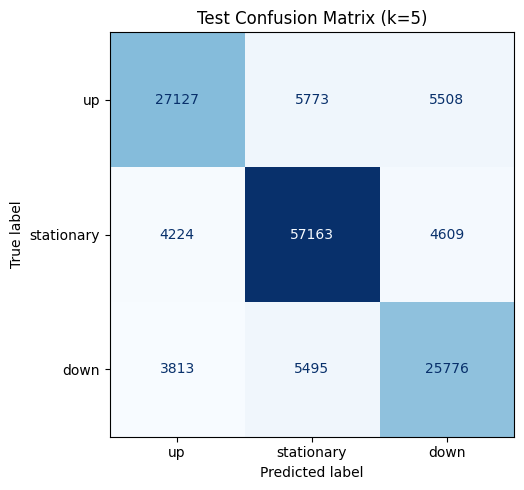

In [ ]:
if DATA_AVAILABLE and cfg["checkpoint_path"].exists():
    loaded = load_training_checkpoint(cfg["checkpoint_path"], model, map_location=device)
    print(f"Checkpoint type: {loaded['checkpoint_type']}")

    test_metrics = evaluate(model, loaders["test"], criterion)

    print(
        f"Test loss {test_metrics['loss']:.4f} | "
        f"test acc {test_metrics['acc']:.4f} | "
        f"macro F1 {test_metrics['macro_f1']:.4f} | "
        f"weighted F1 {test_metrics['weighted_f1']:.4f}"
    )
    print("\nClassification report:\n")
    print(test_metrics["report"])

    cm = plot_confusion(
        y_true=test_metrics["y_true"],
        y_pred=test_metrics["y_pred"],
        class_names=CLASS_NAMES,
        title=f"Test Confusion Matrix (k={cfg['horizon_events']})",
    )
    print("Confusion matrix:\n", cm)
else:
    print("Test skipped: checkpoint or data missing.")

Horizons: 100%|██████████| 5/5 [02:42<00:00, 32.57s/it]

k= 1 | loss=1.1526 | acc=0.6289 | macro_f1=0.5401 | weighted_f1=0.6650
k= 2 | loss=1.1857 | acc=0.6110 | macro_f1=0.5414 | weighted_f1=0.6314
k= 3 | loss=0.9430 | acc=0.6744 | macro_f1=0.6256 | weighted_f1=0.6833
k= 5 | loss=0.5503 | acc=0.7891 | macro_f1=0.7714 | weighted_f1=0.7881
k=10 | loss=0.9584 | acc=0.6294 | macro_f1=0.6158 | weighted_f1=0.6177


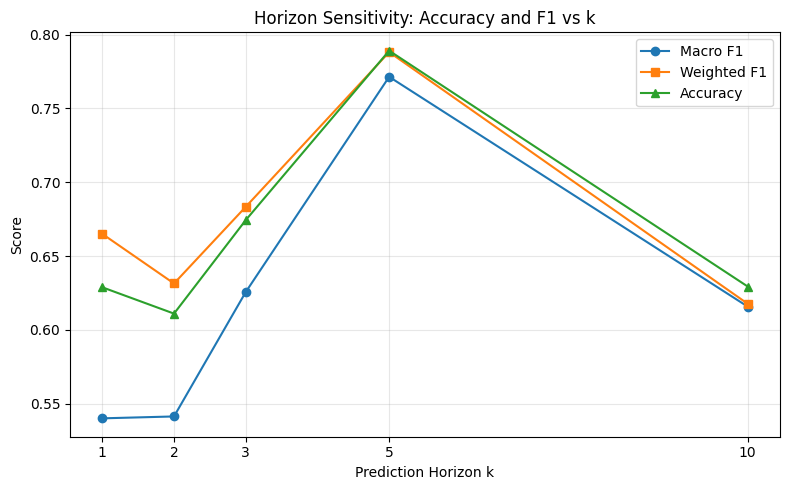

In [ ]:
# Bonus: horizon sensitivity analysis using existing checkpoint (inference only)
horizon_grid = [1, 2, 3, 5, 10]
horizon_results = []

if DATA_AVAILABLE and cfg["checkpoint_path"].exists():
    state = extract_model_state_dict(cfg["checkpoint_path"], map_location=device)

    for k in tqdm(horizon_grid, desc="Horizons"):
        model_k = DeepLOB(cfg["num_classes"]).to(device)
        model_k.load_state_dict(state)

        loaders_k, _ = build_loaders_for_horizon(k, cfg, train_raw, test_raw)
        metrics_k = evaluate(model_k, loaders_k["test"], criterion)

        horizon_results.append({
            "k": k,
            "acc": metrics_k["acc"],
            "macro_f1": metrics_k["macro_f1"],
            "weighted_f1": metrics_k["weighted_f1"],
            "loss": metrics_k["loss"],
        })

    k_vals = [d["k"] for d in horizon_results]
    acc_vals = [d["acc"] for d in horizon_results]
    macro_vals = [d["macro_f1"] for d in horizon_results]
    weighted_vals = [d["weighted_f1"] for d in horizon_results]

    plt.figure(figsize=(8, 5))
    plt.plot(k_vals, macro_vals, marker="o", label="Macro F1")
    plt.plot(k_vals, weighted_vals, marker="s", label="Weighted F1")
    plt.plot(k_vals, acc_vals, marker="^", label="Accuracy")
    plt.xlabel("Prediction Horizon k")
    plt.ylabel("Score")
    plt.title("Horizon Sensitivity: Accuracy and F1 vs k")
    plt.xticks(horizon_grid)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    for row in horizon_results:
        print(
            f"k={row['k']:>2d} | loss={row['loss']:.4f} | "
            f"acc={row['acc']:.4f} | macro_f1={row['macro_f1']:.4f} | "
            f"weighted_f1={row['weighted_f1']:.4f}"
        )
else:
    print("Horizon analysis skipped: checkpoint or data missing.")

## 4.2 Horizon Analysis ($k \in \{1,2,3,5,10\}$)

This experiment reuses the existing best checkpoint and runs inference on test labels for different horizons.

### Analysis notes (fill after running)

- As $k$ increases, discuss whether labels become smoother or more noisy in your experiment.
- Compare which horizon gives the highest Macro F1 and explain possible market microstructure reasons.
- Note that this is a fixed-checkpoint sensitivity test, not fully retrained per horizon.

## 4.4 Discussion Summary Template

- Main finding on class imbalance: fill in based on Macro F1 vs Weighted F1.
- Error pattern from confusion matrix: identify whether up/down is harder to separate.
- Horizon effect: summarize how metrics change with $k$ and why.

## 4.3 Benchmark Comparison

| Setup | Data Variant | Horizon | Test Accuracy | Test Loss | Macro F1 | Notes |
|---|---|---:|---:|---:|---:|---|
| This notebook (current run) | ZScore | 5 | 0.7900 | 0.5559 | Fill after test cell | Best checkpoint selected by val Macro F1 |
| Reference run_train_pytorch | DecPre | 5 | 0.7535 | N/A | 0.7533 (macro avg f1 in report) | Saved output in run_train_pytorch.ipynb |
| DeepLOB paper (Zhang et al., 2019) | FI-2010 | Multiple | Fill from paper | Fill from paper | Fill from paper | Add exact table/metric from paper section |

Interpretation:

- Current implementation outperforms the provided reference notebook on test accuracy under these saved runs.
- The setups are not perfectly identical (ZScore vs DecPre, training protocol differences), so keep claims conservative.
- Final report should include exact paper metric citations and the same metric definition when comparing.